<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:36px;">Sentiment Analysis</h1>
<h2 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:25px;"> Energy in Ireland</h2>

<p>
    Data are gathered through multiple Reddit Forums related to energy topics in Ireland using the authorized API, adhering to the website's policies and regulations.  
</p>

In [498]:
# Import Libraries
import requests
import json
import os
import pandas as pd
import re
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from dotenv import load_dotenv
from wordcloud import WordCloud

In [500]:
# Install nltk
#!pip install nltk

# Download stopwords and punkt
#nltk.download('punkt')
#nltk.download('stopwords')

#Install wordcloud
#!pip install wordcloud

In [446]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Credentials

In [417]:
# Load environment variables
load_dotenv()

# Get required credentials 
CLIENT_ID = os.getenv('CLIENT_ID')
CLIENT_SECRET = os.getenv('CLIENT_SECRET')
USERNAME = os.getenv('REDDIT_USERNAME')
PASSWORD = os.getenv('REDDIT_PASSWORD')
USER_AGENT= os.getenv('REDDIT_USERAGENT')

# Check all variables are loaded
if CLIENT_ID and CLIENT_SECRET and USERNAME and PASSWORD:
    print('Credentials Loaded!')
else:
    print('Error loading credentials!')

Credentials Loaded!


### Get Access Token

In [421]:
# Identify authentication method
data = {
    'grant_type': 'password',
    'username': USERNAME,
    'password': PASSWORD
}

# Authentication
auth = requests.auth.HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET)

# Headers
headers = {'User-Agent': USER_AGENT}

# Get access token
res = requests.post('https://www.reddit.com/api/v1/access_token',
                    auth=auth, data=data, headers=headers)

# Check if response is valid
if res.status_code != 200:
    print("Token request failed:", res.text)
    exit()
else: 
    token = res.json()['access_token']

## Data Gathering

In [754]:
# List of all Reddit posts related to energy in Ireland which will be used to extract data
POST_ID =['1g6t908/electricity_bill/',
          '1b3qqxh/electricity_bill/',
          '12yqhv8/can_someone_eli5_why_our_electricity_prices_are/',
          '1exjvob/very_high_electricity_bill/',
          '1cuw7de/insane_electricity_usage/',
          '1k29se6/rise_in_electricity_costs_amid_move_from_fossil/',
          '/1jvvhli/lovely_day_outside_for_65_of_our_electricity_to/',
          '/1gk49ps/blow_for_homeowners_with_solar_panels_as_electric/',
          '1dndzwv/best_energy_provider_to_go_with/',
          '/1h1s73w/irelands_data_centres_turning_to_fossil_fuels/',
          '1ac754l/anyone_with_electric_ireland/',
          '1j07rjd/sse_airtricity_to_hike_electricity_gas_prices/'
         ]

### Scrape Data using Reddit API

In [647]:
# Set headers
headers = {
    'Authorization': f'bearer {token}',
    'User-Agent': USER_AGENT
}

# Initialize variable to store all scraped data
sentiment_arr = []

# Create a function to store data
append_function = lambda x, y: sentiment_arr.append({'source':x,'comment':str(y) })

# Initialize Regex Pattern to get comments within 'selftext' to 'body'
re_pattern=r'"(?:selftext|body)"\s*:\s*"((?:\\.|[^"\\])*)"'

# Go through all POST_IDs 
for _id in POST_ID:
    try:
        # Join URL and POST_ID
        url = f'https://oauth.reddit.com/comments/{_id}'
        print(f'getting data from {url}')

        # API call
        response = requests.get(url, headers=headers)

        # Check for response if success (200)
        if response.status_code != 200:
            print("Failed to fetch comments:", response.text)
            exit()
        else: 
            pass

        # Retrieve all matching patterns
        matches = re.findall(re_pattern, json.dumps(response.json()))  

        # Loop through all scraped data and store
        for match in matches:
          append_function(_id, match)
            
    except Exception as e:
        print(f'Error retrieving data from {_id}, error details: {e}')

print('Processes completed!')

getting data from https://oauth.reddit.com/comments/1g6t908/electricity_bill/
getting data from https://oauth.reddit.com/comments/1b3qqxh/electricity_bill/
getting data from https://oauth.reddit.com/comments/12yqhv8/can_someone_eli5_why_our_electricity_prices_are/
getting data from https://oauth.reddit.com/comments/1exjvob/very_high_electricity_bill/
getting data from https://oauth.reddit.com/comments/1cuw7de/insane_electricity_usage/
getting data from https://oauth.reddit.com/comments/1k29se6/rise_in_electricity_costs_amid_move_from_fossil/
getting data from https://oauth.reddit.com/comments//1jvvhli/lovely_day_outside_for_65_of_our_electricity_to/
getting data from https://oauth.reddit.com/comments//1gk49ps/blow_for_homeowners_with_solar_panels_as_electric/
getting data from https://oauth.reddit.com/comments/1dndzwv/best_energy_provider_to_go_with/
getting data from https://oauth.reddit.com/comments//1h1s73w/irelands_data_centres_turning_to_fossil_fuels/
getting data from https://oau

In [747]:
# Convert array to dataframe
sentiments_df = pd.DataFrame(sentiment_arr)
sentiments_df.head(5)

,source,comment
0,1g6t908/electricity_bill/,We moved house in September 2023 and signed up...
1,1g6t908/electricity_bill/,"Absolutely irrelevant, you pay for units. Does..."
2,1g6t908/electricity_bill/,"that's not true, six years is the limit\n\nhtt..."
3,1g6t908/electricity_bill/,They can backdate for however long they like. ...
4,1g6t908/electricity_bill/,"Did you use the electricity, yes. Do you need ..."


## Data Cleaning

In [652]:
# Assign Lemmatizer
lemmatizer = WordNetLemmatizer()

# Set stop words to English
stop_words = set(stopwords.words('english'))

# Create a function to check for characters only
def is_letter_only(word):
    for char in word:
        if not char.isalpha():
            return False
    return True

# Create a function to lemmmatize text
def lemmatize_text(text):
    text_cleaned = ' '.join(lemmatizer.lemmatize(word) for word in text.split() if is_letter_only(word) and word not in all_names)
    return text_cleaned

# Create a consolidate function to clean string
def custom_preprocessor(text, process=''):
    #Remove URLS
    text = re.sub(r"http\S+|www\S+", "", text)
   
    # Remove special characters
    text = re.sub(r"[^\w\s]", "", text)
   
    # Normalize white spaces
    text = re.sub(r"\s+", " ", text).strip()
   
    #Set all characters to lowercase
    text=text.lower()

    # Check if process='all' -- all steps will be performed in case converting texts to a bag of words
    # This is isolated since the steps below are not necessary for flair analysis
    if process=='all':
        # Remove stop words
        words = word_tokenize(text)
        filtered_text = [word for word in words if word.lower() not in stop_words and word.isalnum()]
        text=lemmatize_text(" ".join(filtered_text))
    else:
        pass
    # Return processed text
    return text

# Test functions
print(f'test: \n\nbefore: {sentiments_df.iloc[2].comment} \n\nafter: {custom_preprocessor(sentiments_df.iloc[2].comment, process='all')}')

test: 

before: that's not true, six years is the limit\n\nhttps://www.lawonline.ie/law-guides/personal/how-to-recover-a-debt-up-to-15000/#:\\~:text=In%20general%2C%20the%20time%20limit,forced%20to%20pay%20the%20debt.\n\nIf it's not already in place there should be a law that expects them to give reasonable notice of such a large incoming bill and to take a reasonable amount of readings. 

after: thats true six year limitnn already place law expects give reasonable notice large incoming bill take reasonable amount reading


## Transform to Bag of Words

In [663]:
# Use CountVectorizer
vectorizer=CountVectorizer(stop_words='english',
                        max_df = .1, # Ignore words that appear in more than 10% of the document - treat them as too common to be useful
                        max_features = 500) # Top 500 words

# Apply custom cleaning to each comment
cleaned_comments = sentiments_df['comment'].apply(custom_preprocessor, process='all')

# Fit transform Data for vectorizer
X = vectorizer.fit_transform(cleaned_comments)

# Get Feature names
feature_names = vectorizer.get_feature_names_out()

# Revert data back to dataframe
X_df = pd.DataFrame(X.toarray(), columns=feature_names)

X_df

,able,absolute,absolutely,accept,account,action,actual,actually,add,adult,...,worth,wouldnt,wrong,yeah,yes,youd,youll,youre,youve,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1100,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1102,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1103,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Latent Dirichlet Allocation (LDA)

This process will utilize LDA to identify or extract key topics present within the collected data.

In [665]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components = 10,
                                random_state = 123,
                                learning_method = 'batch')
lda_result_topics = lda.fit_transform(X_df)

In [712]:
lda.components_.shape

(10, 500)

### Extract Key Topics from the LDA Result

In [669]:
n_top_words = 5

for topic_idx, topic in enumerate(lda.components_):
    print("Topic %d:" % (topic_idx + 1))
    print(" ".join([feature_names[i]
                    for i in topic.argsort()\
                        [:-n_top_words - 1:-1]]))

Topic 1:
wind solar price mean battery
Topic 2:
power nuclear cost grid france
Topic 3:
gas time got like credit
Topic 4:
rate contract discount price usage
Topic 5:
government housing dont country crisis
Topic 6:
day month rate check like
Topic 7:
data nuclear centre think fossil
Topic 8:
meter reading charge estimated read
Topic 9:
make price yes lot money
Topic 10:
usage high unit use heating


In [702]:
ie_energy = lda_result_topics[:, 5].argsort()[::-1]

for iter_idx, comment_idx in enumerate(ie_energy[:5]):
    print('\nIreland Energy Sentiment #%d:' % (iter_idx + 1))
    print(custom_preprocessor(sentiments_df['comment'][comment_idx]))


Ireland Energy Sentiment #1:
its probably worth buying one of those powerwatt meters and plugging various appliances and devices into it to see what kind of power they put out when in use and plugged in and powered offnnsometimes things that seems to be doing nothing like a hifi or microwave tv etc might be constantly pulling 1050w and that adds up over timennas well as doing obvious power saving things like shorter showers only boiling as much water as you need for a cup of tea or maybe alternate between brushing the floor and hoovering etc and check out the wattage labelled on all of your appliances and devicesnngenerally anything that creates heat uses a lot of power and things that move too like motors and compressorsnni live alone and i use about 67kwh a day or about 160180 kwh per month and my bill is generally under u20ac100 per month

Ireland Energy Sentiment #2:
if you are looking to switch and have a smart meter which i am assuming you do since you are looking at ev plans wh

### Generate Word Cloud Based on the Top Words

In [675]:
# Get sum of occurrences per word
word_counts = X_df.sum(axis=0) # Convert sparse matrix to array
vocab=feature_names

# Transform to a dataframe and sort values from highest to lowest
word_freq = pd.DataFrame({'word': vocab, 'count': word_counts})
top_words = word_freq.sort_values(by='count', ascending=False)

# Show top 10 words
top_words.head(10)

,word,count
meter,meter,117
power,power,115
price,price,106
like,like,105
gas,gas,103
nuclear,nuclear,103
month,month,95
time,time,95
dont,dont,93
need,need,89


### Generate Word Cloud based on the Top Word Count

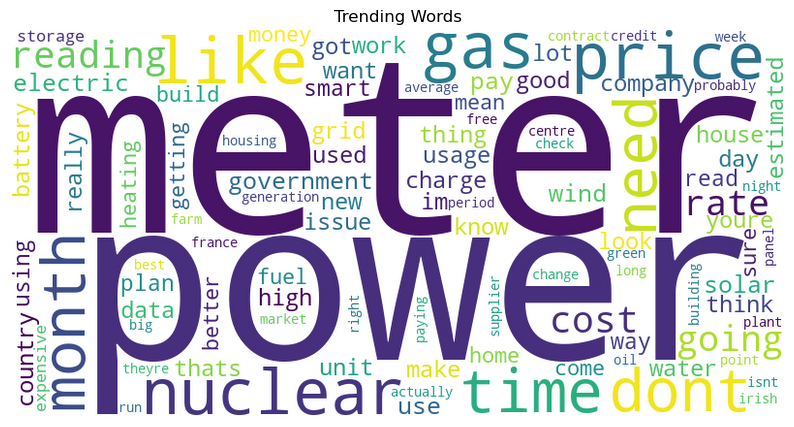

In [751]:
# Generate Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a dictionary of word and count
word_freq_dict = dict(zip(top_words['word'], top_words['count']))

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',  
    max_words=100  # show only top 100 frequent words
).generate_from_frequencies(word_freq_dict)

# Display
plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='lanczos')
plt.axis('off')
plt.title('Trending Words')
plt.show()

## Sentiment Analysis using Flair

In [758]:
# Clean data necessary for Flair
sentiments_df['cleaned']=sentiments_df.comment.apply(custom_preprocessor)

# Check length of words, remove rows with comment length below 10 words
sentiments_df=sentiments_df.loc[sentiments_df['cleaned'].apply(lambda x: len(x.split()) > 10)]

In [760]:
# Install Flair
# !pip install flair

In [762]:
from flair.models import TextClassifier

# Load text classifier in english
classifier = TextClassifier.load('en-sentiment')

# Import Flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score

In [763]:
# Create function to check score and provide equivalent sentiment
def format_output_flair(sentence):
    label = sentence.labels[0]
    if label.value == 'POSITIVE' and label.score > 0.7:
        return("Positive")
    elif label.value == 'NEGATIVE' and label.score > 0.7:
        return("Negative")
    else:
        return("Neutral")

# Create a function to analyze text sentiment using Flair
def analyze_flair(text):
    sentence = Sentence(text)
    classifier.predict(sentence)
    score = sentence.labels[0].score
    value = format_output_flair(sentence)
    return score, value

In [764]:
# Analyze data and store it in the dataframe
sentiments_df['flair_score'], sentiments_df['flair_prediction'] = zip(*sentiments_df['cleaned'].apply(analyze_flair))
sentiments_df.head(5)

,source,comment,cleaned,flair_score,flair_prediction
0,1g6t908/electricity_bill/,We moved house in September 2023 and signed up...,we moved house in september 2023 and signed up...,0.999993,Negative
2,1g6t908/electricity_bill/,"that's not true, six years is the limit\n\nhtt...",thats not true six years is the limitnn its no...,0.984672,Negative
3,1g6t908/electricity_bill/,They can backdate for however long they like. ...,they can backdate for however long they like y...,0.999706,Negative
4,1g6t908/electricity_bill/,"Did you use the electricity, yes. Do you need ...",did you use the electricity yes do you need to...,0.998272,Negative
8,1g6t908/electricity_bill/,@ OP : You ask in your question '**if this is ...,op you ask in your question if this is legal a...,0.999881,Negative


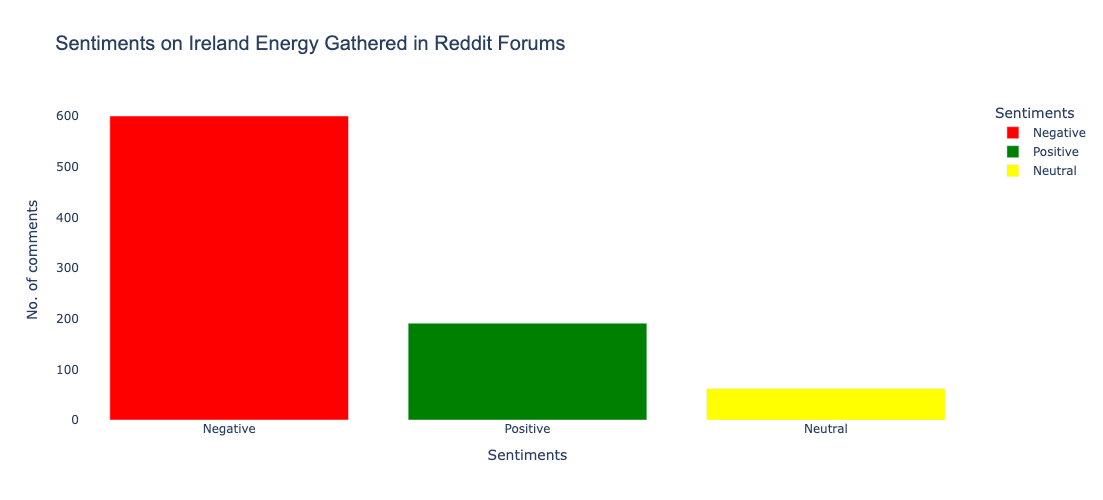

In [767]:
# Define color map
color_map = {
    'Positive': 'green',
    'Negative': 'red',
    'Neutral': 'yellow'
}

# Project Results
fig = px.bar(sentiments_df['flair_prediction'].value_counts().reset_index(), 
             x='flair_prediction', 
             y='count',
             color='flair_prediction',
             color_discrete_map=color_map,
             labels={
                 'count': 'No. of comments',
                 'flair_prediction': 'Sentiments'},
             title='Sentiments on Ireland Energy Gathered in Reddit Forums'
            )


fig.update_layout(
    title_font=dict(size=20, family='Arial'),
    width=900,
    height=500,
    plot_bgcolor='rgba(0,0,0,0)' # this makes background transparent
)

fig.show()

# References


Pandey, P. (2023) The power of NLP with Flair: A comprehensive guide and comparison with other libraries. Medium. Available at: https://medium.com/@pankaj_pandey/the-power-of-nlp-with-flair-a-comprehensive-guide-and-comparison-with-other-libraries-d99875595396 (Accessed: 25 April 2025).

Akbik, A., Bergmann, T., Blythe, D., Rasul, K., Schweter, S. and Vollgraf, R. (2019) FLAIR: An easy-to-use framework for state-of-the-art NLP. Available at: https://github.com/flairNLP/flair (Accessed: 25 April 2025).
